In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors as mcolors
from scipy.stats import linregress
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans
from tabulate import tabulate
from collections import Counter

%matplotlib inline

In [2]:
df = pd.read_csv('Data/customer_data_pca.csv', encoding="ISO-8859-1")
customer_data_pca = df

In [3]:
customer_data_pca.head()

,CustomerID,PC1,PC2,PC3,PC4,PC5,PC6
0,12347.0,3.216448,-1.479686,1.972139,1.091774,-0.505431,0.264377
1,12348.0,0.659357,0.586927,0.653150,1.049354,-1.013580,2.190523
2,12350.0,-2.350524,-0.568342,0.673564,-0.330117,1.086585,1.858286
3,12352.0,0.605909,-1.460041,-0.856529,0.815976,-0.474489,0.344381
4,12353.0,-2.722626,0.509585,-0.437499,0.373808,0.490735,1.860667


In [4]:
print(df.dtypes)

CustomerID    float64
PC1           float64
PC2           float64
PC3           float64
PC4           float64
PC5           float64
PC6           float64
dtype: object


In [5]:
customer_data_pca.set_index('CustomerID', inplace=True)

In [6]:
customer_data_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6
CustomerID,,,,,,
12347.0,3.216448,-1.479686,1.972139,1.091774,-0.505431,0.264377
12348.0,0.659357,0.586927,0.653150,1.049354,-1.013580,2.190523
12350.0,-2.350524,-0.568342,0.673564,-0.330117,1.086585,1.858286
12352.0,0.605909,-1.460041,-0.856529,0.815976,-0.474489,0.344381
12353.0,-2.722626,0.509585,-0.437499,0.373808,0.490735,1.860667


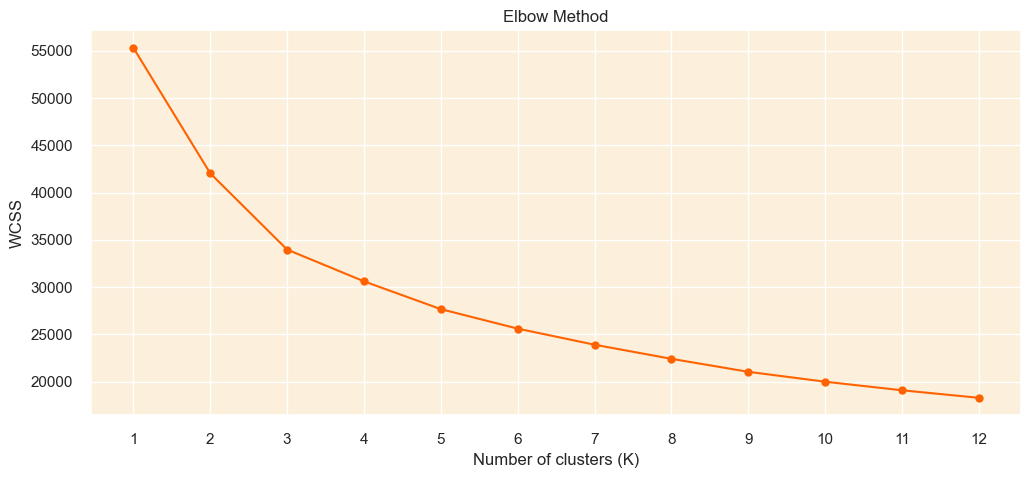

In [7]:
# Thiết lập kiểu hiển thị biểu đồ và màu nền
sns.set_theme(style='darkgrid', rc={'axes.facecolor': '#fcf0dc'})

# Thiết lập bảng màu cho biểu đồ
sns.set_palette(['#ff6200'])

# Vẽ biểu đồ Elbow để xác định số lượng cụm tối ưu
wcss = []
ks = range(1, 13)
for k in ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=30, max_iter=5000, random_state=0)
    km.fit(customer_data_pca)
    wcss.append(km.inertia_)
plt.figure(figsize=(12,5))
plt.plot(list(ks), wcss, marker='o')
plt.xticks(list(ks))
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [8]:
def silhouette_analysis(df, start_k, stop_k, figsize=(10, 4)):
    # Đảm bảo đầu vào là mảng số
    X = df.values if hasattr(df, "values") else df

    sns.set_palette(["darkorange"])
    ks = list(range(start_k, stop_k + 1))
    silhouette_scores = []

    for k in ks:
        km = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=30,
            max_iter=5000,
            random_state=0
        )
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)

    best_idx = int(np.argmax(silhouette_scores))
    best_k = ks[best_idx]
    best_score = silhouette_scores[best_idx]

    plt.figure(figsize=figsize)
    plt.plot(ks, silhouette_scores, marker="o", color="darkorange")
    plt.xticks(ks)
    plt.xlabel("Số cụm (k)")
    plt.ylabel("Điểm Silhouette")
    plt.title("Điểm Silhouette trung bình theo k", fontsize=14)

    # Highlight k tối ưu
    plt.axvline(best_k, linestyle="--", color="gray", alpha=0.8)
    plt.scatter([best_k], [best_score], color="red", zorder=3)
    plt.text(
        best_k + 0.2,
        best_score,
        f"best k={best_k}, score={best_score:.3f}",
        fontsize=10,
        bbox=dict(facecolor="#fcc36d", edgecolor="#ff6200", boxstyle="round,pad=0.3")
    )

    plt.tight_layout()
    plt.show()

    return best_k, best_score, silhouette_scores


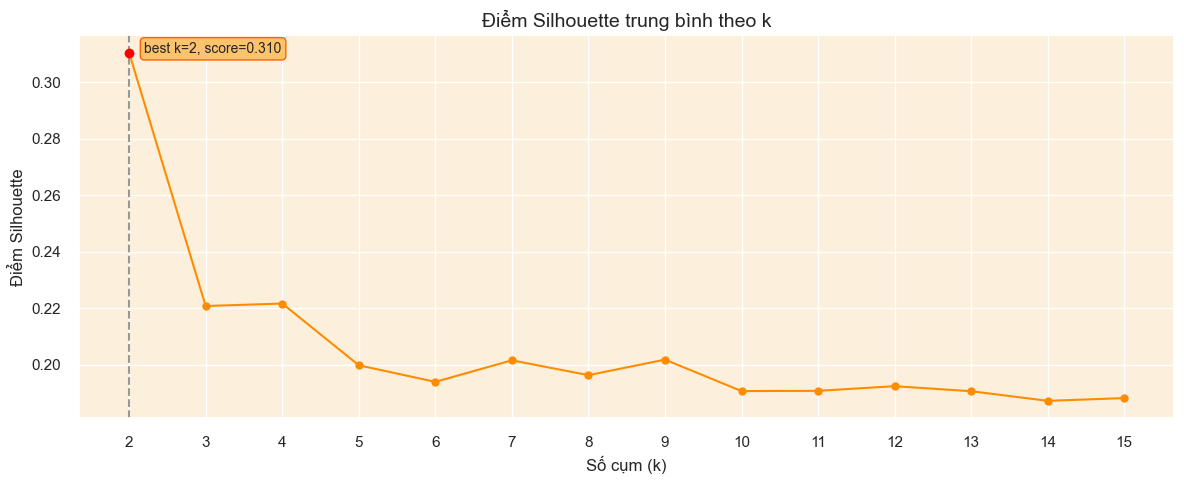

In [9]:
best_k, best_score, scores = silhouette_analysis(customer_data_pca, 2, 15, figsize=(12, 5))

In [10]:
customer_data_cleaned = pd.read_csv('Data/customer_data_cleaned.csv', encoding="ISO-8859-1")

In [11]:
from sklearn.cluster import KMeans
from collections import Counter
import numpy as np

# Áp dụng thuật toán KMeans với số cụm tối ưu (k = 2)
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=30, max_iter=5000, random_state=0)

# Huấn luyện mô hình trên dữ liệu đã được giảm chiều bằng PCA
kmeans.fit(customer_data_pca)

# Đếm số lượng phần tử trong từng cụm
cluster_frequencies = Counter(kmeans.labels_)

# Tạo ánh xạ từ nhãn cụm cũ sang nhãn cụm mới dựa trên tần suất xuất hiện
# Cụm có nhiều khách hàng nhất sẽ là 1, cụm còn lại sẽ là 2
sorted_clusters = [label for label, _ in cluster_frequencies.most_common()]
label_mapping = {sorted_clusters[0]: 1, sorted_clusters[1]: 2}

# Áp dụng ánh xạ mới để thay đổi nhãn cụm
new_labels = np.array([label_mapping[label] for label in kmeans.labels_])

# Gán nhãn cụm mới vào dataset gốc (dữ liệu ban đầu trước PCA)
customer_data_cleaned['cluster'] = new_labels

# Gán nhãn cụm mới vào dataset đã qua PCA
customer_data_pca['cluster'] = new_labels


In [12]:
# Display the first few rows of the original dataframe
customer_data_cleaned.head()

,CustomerID,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Unique_Products_Purchased,Average_Days_Between_Purchases,Day_Of_Week,Hour,Is_UK,Cancellation_Frequency,Cancellation_Rate,Monthly_Spending_Mean,Monthly_Spending_Std,Spending_Trend,cluster
0,12347.0,2,7,2458,4310.00,615.714286,103,2.016575,1,14,0,0,0.000,615.714286,341.070789,4.486071,2
1,12348.0,75,4,2332,1437.24,359.310000,21,10.884615,3,19,0,0,0.000,359.310000,203.875689,-100.884000,1
2,12350.0,310,1,196,294.40,294.400000,16,700.000000,2,16,0,0,0.000,294.400000,0.000000,0.000000,1
3,12352.0,36,8,526,1385.74,173.217500,57,3.132530,1,14,0,1,0.125,346.435000,120.042154,-2.682000,1
4,12353.0,204,1,20,89.00,89.000000,4,700.000000,3,17,0,0,0.000,89.000000,0.000000,0.000000,1


# Clustering Evaluation


In [13]:
# Setting up the color scheme for the clusters (RGB order)
colors = ['#e8000b', '#1ac938', '#023eff']

In [14]:
import plotly.graph_objects as go

# Giả sử colors đã được định nghĩa trước đó
colors = ['red', 'blue']  # Định nghĩa lại nếu cần

# Tạo các DataFrame riêng biệt cho từng cụm
cluster_1 = customer_data_pca[customer_data_pca['cluster'] == 1]
cluster_2 = customer_data_pca[customer_data_pca['cluster'] == 2]

# Tạo biểu đồ 3D Scatter bằng Plotly
fig = go.Figure()

# Thêm các điểm dữ liệu của từng cụm vào biểu đồ với màu sắc khác nhau
fig.add_trace(go.Scatter3d(x=cluster_1['PC1'], y=cluster_1['PC2'], z=cluster_1['PC3'],
                           mode='markers', marker=dict(color=colors[0], size=5, opacity=0.4), name='Cluster 1'))
fig.add_trace(go.Scatter3d(x=cluster_2['PC1'], y=cluster_2['PC2'], z=cluster_2['PC3'],
                           mode='markers', marker=dict(color=colors[1], size=5, opacity=0.4), name='Cluster 2'))

# Thiết lập tiêu đề và bố cục của biểu đồ
fig.update_layout(
    title=dict(text='3D Visualization of Customer Clusters in PCA Space', x=0.5),
    scene=dict(
        xaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC1'),
        yaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC2'),
        zaxis=dict(backgroundcolor="#fcf0dc", gridcolor='white', title='PC3'),
    ),
    width=900,
    height=800
)

# Hiển thị biểu đồ
fig.show()

# Cluster Distribution Visualization

**Sử dụng biểu đồ cột để trực quan hóa tỷ lệ phần trăm khách hàng trong từng cụm, giúp hiểu rõ liệu các cụm có cân bằng và có ý nghĩa hay không.**

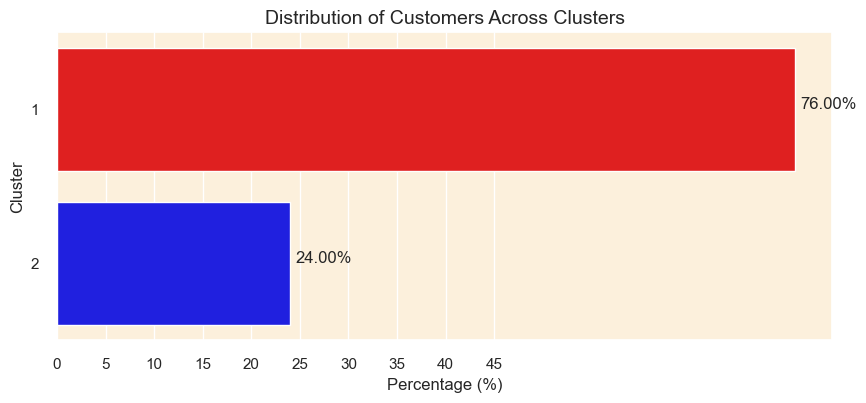

In [15]:
# Tính phần trăm khách hàng trong từng cụm (cluster)
cluster_percentage = (customer_data_pca['cluster'].value_counts(normalize=True) * 100).reset_index()

# Đặt lại tên cột cho DataFrame
cluster_percentage.columns = ['Cluster', 'Percentage']

# Sắp xếp các cụm theo thứ tự tăng dần
cluster_percentage.sort_values(by='Cluster', inplace=True)

# Thiết lập kích thước của biểu đồ
plt.figure(figsize=(10, 4))

# Vẽ biểu đồ thanh ngang thể hiện tỷ lệ khách hàng trong từng cụm
sns.barplot(x='Percentage', y='Cluster', data=cluster_percentage, orient='h', palette=colors)

# Thêm nhãn phần trăm lên trên các thanh
for index, value in enumerate(cluster_percentage['Percentage']):
    plt.text(value+0.5, index, f'{value:.2f}%')  # Dịch chuyển nhãn sang phải 0.5 đơn vị để dễ đọc

# Đặt tiêu đề cho biểu đồ
plt.title('Distribution of Customers Across Clusters', fontsize=14)

# Thiết lập khoảng cách giữa các giá trị trên trục X, mỗi 5%
plt.xticks(ticks=np.arange(0, 50, 5))

# Đặt nhãn cho trục X
plt.xlabel('Percentage (%)')

# Hiển thị biểu đồ
plt.show()


### **Phân bố khách hàng theo cụm**
- **Cụm 1** chứa **76%** khách hàng, chiếm đa số.
- **Cụm 2** chỉ chiếm **24%**, ít hơn đáng kể.

**Vấn đề:**  
- Cụm 1 quá lớn so với cụm 2, điều này có thể cho thấy **mô hình phân cụm chưa thực sự cân bằng**.
- Nếu một cụm chứa phần lớn dữ liệu, có thể **các cụm chưa thực sự khác biệt rõ ràng**.

### **Ý nghĩa kinh doanh**
**Nếu cụm 1 thực sự chiếm đa số một cách hợp lý**, có thể phân tích sâu hơn:
- **Cụm 1 (76%)**: Đây có thể là nhóm khách hàng phổ biến nhất, có hành vi mua sắm chung.
- **Cụm 2 (24%)**: Đây có thể là nhóm khách hàng đặc biệt hơn, có hành vi khác biệt (ví dụ: chi tiêu cao/thấp, mua sắm theo mùa,...).

**Ứng dụng thực tế:**
- Nếu cụm 2 có giá trị cao hơn (ví dụ: chi tiêu nhiều hơn), có thể **tập trung tiếp thị vào nhóm này**.
- Nếu cụm 1 quá chung chung, có thể **cần chia thành nhiều cụm nhỏ hơn** để tìm hiểu chi tiết hơn.


# Evaluation Metrics

Để đánh giá chi tiết hơn về chất lượng của phân cụm sử dụng các chỉ số sau:

- **Silhouette Score**: Chỉ số đo lường khoảng cách giữa các cụm. Giá trị cao hơn cho thấy sự phân tách cụm tốt hơn. Giá trị dao động từ **-1 đến 1**, trong đó **càng gần 1 càng tốt**.
    
- **Calinski-Harabasz Score**: Chỉ số này đánh giá mức độ phân tán giữa và trong các cụm. **Điểm số càng cao, cụm càng rõ ràng và tách biệt**.
    
- **Davies-Bouldin Score**: Chỉ số đo độ tương đồng trung bình giữa mỗi cụm với cụm gần nhất. **Giá trị thấp hơn cho thấy các cụm được phân tách tốt hơn**.

In [16]:
# Compute number of customers
num_observations = len(customer_data_pca)

# Separate the features and the cluster labels
X = customer_data_pca.drop('cluster', axis=1)
clusters = customer_data_pca['cluster']

# Compute the metrics
sil_score = silhouette_score(X, clusters)
calinski_score = calinski_harabasz_score(X, clusters)
davies_score = davies_bouldin_score(X, clusters)

# Create a table to display the metrics and the number of observations
table_data = [
    ["Number of Observations", num_observations],
    ["Silhouette Score", sil_score],
    ["Calinski Harabasz Score", calinski_score],
    ["Davies Bouldin Score", davies_score]
]

# Print the table
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt='pretty'))

+-------------------------+---------------------+
|         Metric          |        Value        |
+-------------------------+---------------------+
| Number of Observations  |        4067         |
|    Silhouette Score     | 0.31038611636094693 |
| Calinski Harabasz Score | 1283.5817934748968  |
|  Davies Bouldin Score   | 1.5336362387066553  |
+-------------------------+---------------------+


- **Silhouette Score** có giá trị **0.31**. Điều này cho thấy các cụm có sự tách biệt nhưng có thể **vẫn có một số điểm bị chồng lấn** giữa các cụm.  

- **Calinski-Harabasz Score** là **1283.58**, **khá cao**, cho thấy cụm dữ liệu được **phân tách rõ ràng và có cấu trúc hợp lý**. Giá trị cao này chứng tỏ **các cụm có sự khác biệt đáng kể về mặt toán học**.

- **Davies-Bouldin Score** đạt **1.53**. Giá trị này **càng thấp càng tốt**, vì nó cho thấy mức độ tương đồng giữa các cụm thấp hơn. Với 1.53, các cụm vẫn có sự khác biệt nhưng có thể **còn một số điểm dữ liệu gần nhau giữa các cụm**.  


# Cluster Analysis and Profiling

Phần này phân tích đặc điểm của từng cụm để hiểu rõ hành vi và sở thích khác biệt của các nhóm khách hàng khác nhau. Đồng thời, tôi cũng sẽ lập hồ sơ cho từng cụm để xác định các đặc điểm chính giúp định hình khách hàng trong mỗi cụm.

## Radar Chart Approach

Trước hết, tôi sẽ tạo biểu đồ radar để trực quan hóa các giá trị trung tâm (centroid) của từng cụm trên các đặc trưng khác nhau. Điều này giúp so sánh nhanh hồ sơ của các cụm khác nhau.  

Để xây dựng biểu đồ radar, trước tiên cần tính toán **centroid** cho từng cụm. Centroid này đại diện cho giá trị trung bình của tất cả các đặc trưng trong một cụm cụ thể. Sau đó, tôi sẽ hiển thị các centroid này trên biểu đồ radar, giúp dễ dàng hình dung xu hướng trung tâm của từng đặc trưng trong các cụm khác nhau.

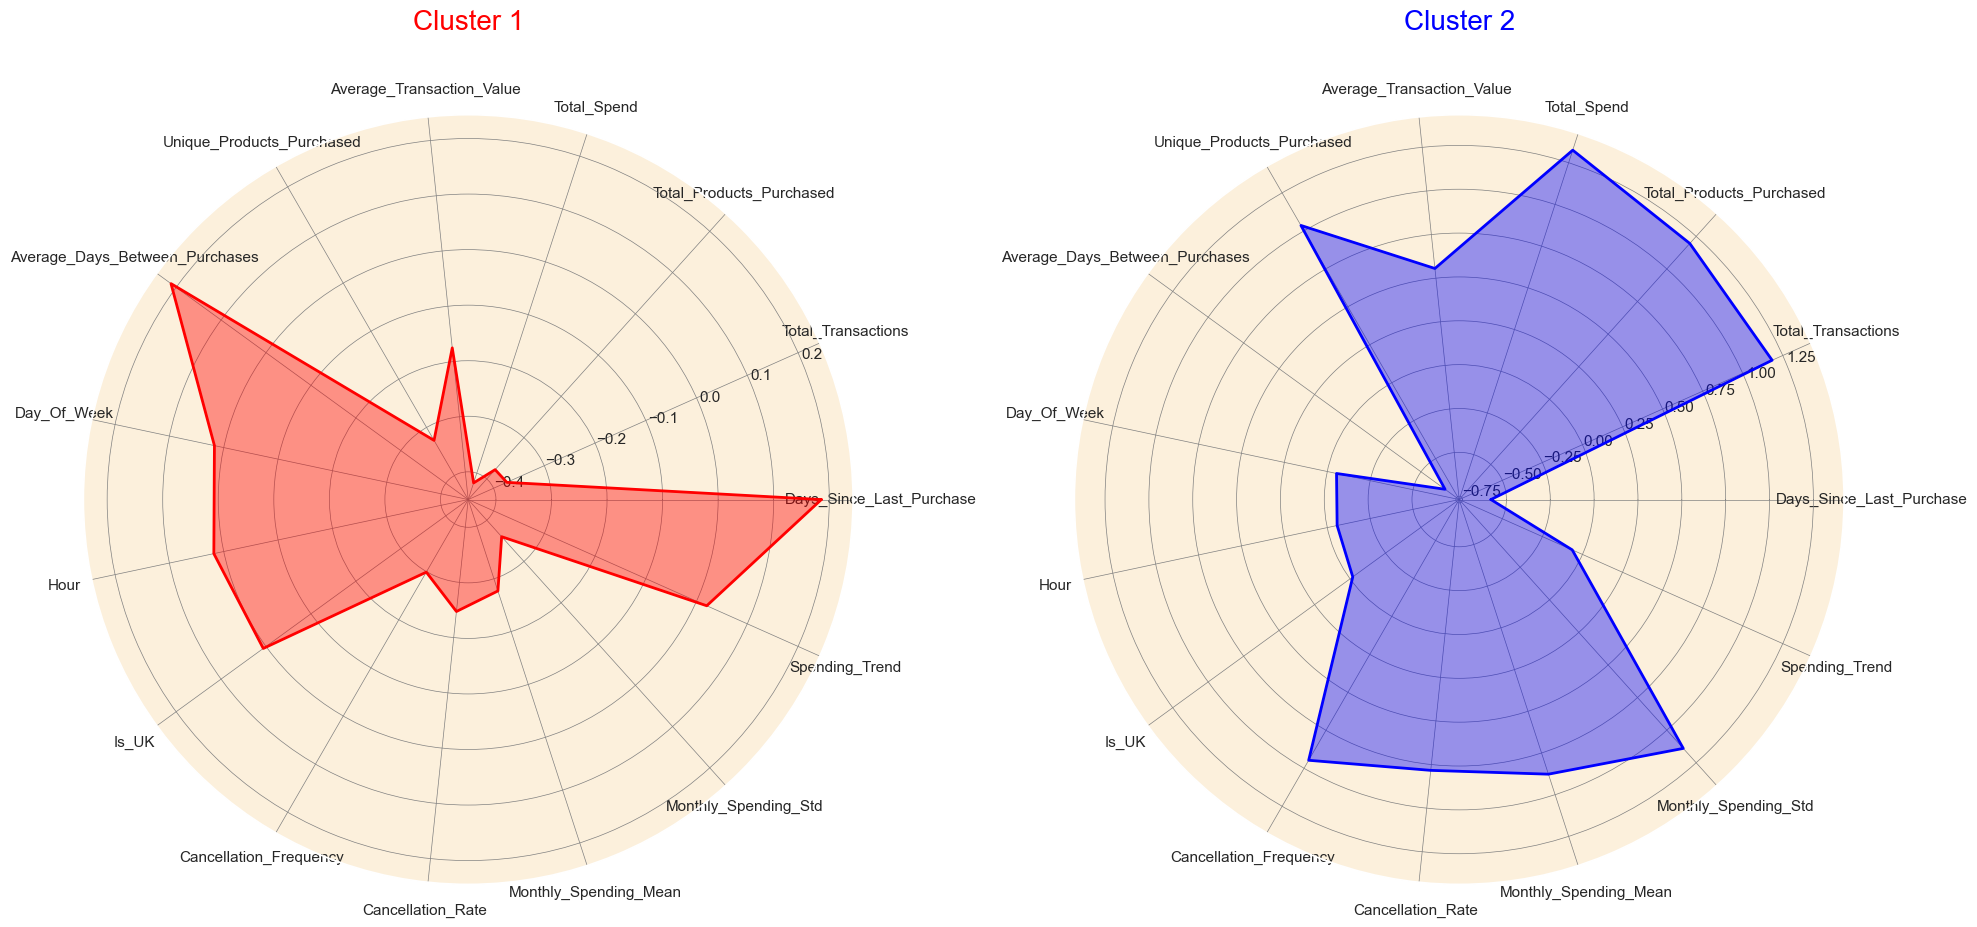

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Đặt 'CustomerID' làm index và tạo dataframe mới
df_customer = customer_data_cleaned.set_index('CustomerID')

# Chuẩn hóa dữ liệu (bỏ cột cluster)
scaler = StandardScaler()
df_customer_standardized = scaler.fit_transform(df_customer.drop(columns=['cluster']))

# Tạo dataframe mới với dữ liệu đã chuẩn hóa và thêm cột cluster lại
df_customer_standardized = pd.DataFrame(df_customer_standardized,
                                        columns=df_customer.columns[:-1],
                                        index=df_customer.index)
df_customer_standardized['cluster'] = df_customer['cluster']

# Tính toán centroid của mỗi cụm
cluster_centroids = df_customer_standardized.groupby('cluster').mean()

# Xác định số cụm thực tế
n_clusters = cluster_centroids.shape[0]  # Sẽ là 2 trong trường hợp này

# Hàm tạo biểu đồ radar chart
def create_radar_chart(ax, angles, data, color, cluster):
    ax.fill(angles, data, color=color, alpha=0.4)
    ax.plot(angles, data, color=color, linewidth=2, linestyle='solid')
    ax.set_title(f'Cluster {cluster+1}', size=20, color=color, y=1.1)

# Lấy danh sách nhãn
labels = np.array(cluster_centroids.columns)
num_vars = len(labels)

# Tính góc của từng trục
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Hoàn thành vòng tròn cho radar chart
labels = np.concatenate((labels, [labels[0]]))
angles += angles[:1]

# Khởi tạo biểu đồ radar với số cụm thực tế
fig, ax = plt.subplots(figsize=(20, 10), subplot_kw=dict(polar=True), nrows=1, ncols=n_clusters)

# Nếu chỉ có 1 cụm, `ax` là một đối tượng, cần chuyển thành danh sách để lặp qua
if n_clusters == 1:
    ax = [ax]

# Vẽ biểu đồ radar cho từng cụm
for i, color in enumerate(colors[:n_clusters]):  # Chỉ lặp qua số cụm thực tế
    data = cluster_centroids.iloc[i].tolist()
    data += data[:1]  # Hoàn thành vòng tròn
    create_radar_chart(ax[i], angles, data, color, i)

    # Thiết lập nhãn trục
    ax[i].set_xticks(angles[:-1])
    ax[i].set_xticklabels(labels[:-1])
    ax[i].grid(color='grey', linewidth=0.5)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

### **Phân tích từ biểu đồ radar theo hình ảnh**
Từ biểu đồ radar có thể nhận thấy:

- **Cụm 1 (Màu đỏ)**
  - **Days_Since_Last_Purchase (Số ngày từ lần mua trước)** cao: **Cho thấy khách hàng không mua sắm thường xuyên**.
  - **Average_Days_Between_Purchases (Trung bình số ngày giữa các lần mua hàng) rất cao**: Nhấn mạnh xu hướng mua sắm gián đoạn.
  - **Day_Of_Week cao**: Họ có xu hướng mua vào **cuối tuần**.
  - **Total_Transactions, Total_Spend, Average_Transaction_Value thấp**: **Chi tiêu ít hơn và giao dịch không thường xuyên**.
  - **Cancellation Rate thấp**: **Họ hiếm khi hủy đơn**.

➡ **Tóm lại**, đây là nhóm khách hàng **mua sắm không thường xuyên**, chủ yếu vào cuối tuần, và có xu hướng **chi tiêu thấp hơn**.

---

- **Cụm 2 (Màu tím)**
  - **Total_Spend, Total_Transactions, Total_Products_Purchased cao**: **Nhóm này chi tiêu cao và mua nhiều sản phẩm hơn**.
  - **Days_Since_Last_Purchase thấp**: Họ **mua sắm gần đây**, cho thấy **tính thường xuyên cao hơn** so với cụm 0.
  - **Spending Trend cao**: Xu hướng chi tiêu **tăng trưởng theo thời gian**.
  - **Cancellation Rate và Cancellation Frequency trung bình**: Nhóm này có một số **lần hủy đơn, nhưng không phải quá cao**.

➡ **Tóm lại**, đây là nhóm khách hàng **chi tiêu nhiều hơn, có xu hướng mua sắm thường xuyên hơn**, và **có khả năng tăng trưởng chi tiêu trong tương lai**.

---

### **Kết luận**
🔹 **Cụm 1 (Đỏ)**: **Khách hàng không thường xuyên**, chi tiêu thấp, chủ yếu mua vào cuối tuần.  
🔹 **Cụm 2 (tím)**: **Khách hàng chi tiêu nhiều hơn**, có xu hướng chi tiêu tăng trưởng, mua sắm thường xuyên hơn.  

**Gợi ý chiến lược kinh doanh**:
- **Cụm 1**: Cần **khuyến khích họ mua sắm thường xuyên hơn**, có thể qua **ưu đãi vào ngày thường** để giảm khoảng cách giữa các giao dịch.
- **Cụm 2**: Đây là **khách hàng tiềm năng**, có thể **tập trung các chương trình ưu đãi VIP, giảm giá theo mức chi tiêu để duy trì và gia tăng chi tiêu của họ**.

# Histogram Chart Approach

Để xác thực các hồ sơ khách hàng được xác định từ biểu đồ radar, chúng ta có thể vẽ biểu đồ histogram cho từng đặc trưng, phân tách theo nhãn cụm. Những biểu đồ này sẽ giúp chúng ta trực quan hóa sự phân bố giá trị của từng đặc trưng trong mỗi cụm, từ đó xác nhận hoặc điều chỉnh các hồ sơ đã tạo dựa trên biểu đồ radar.

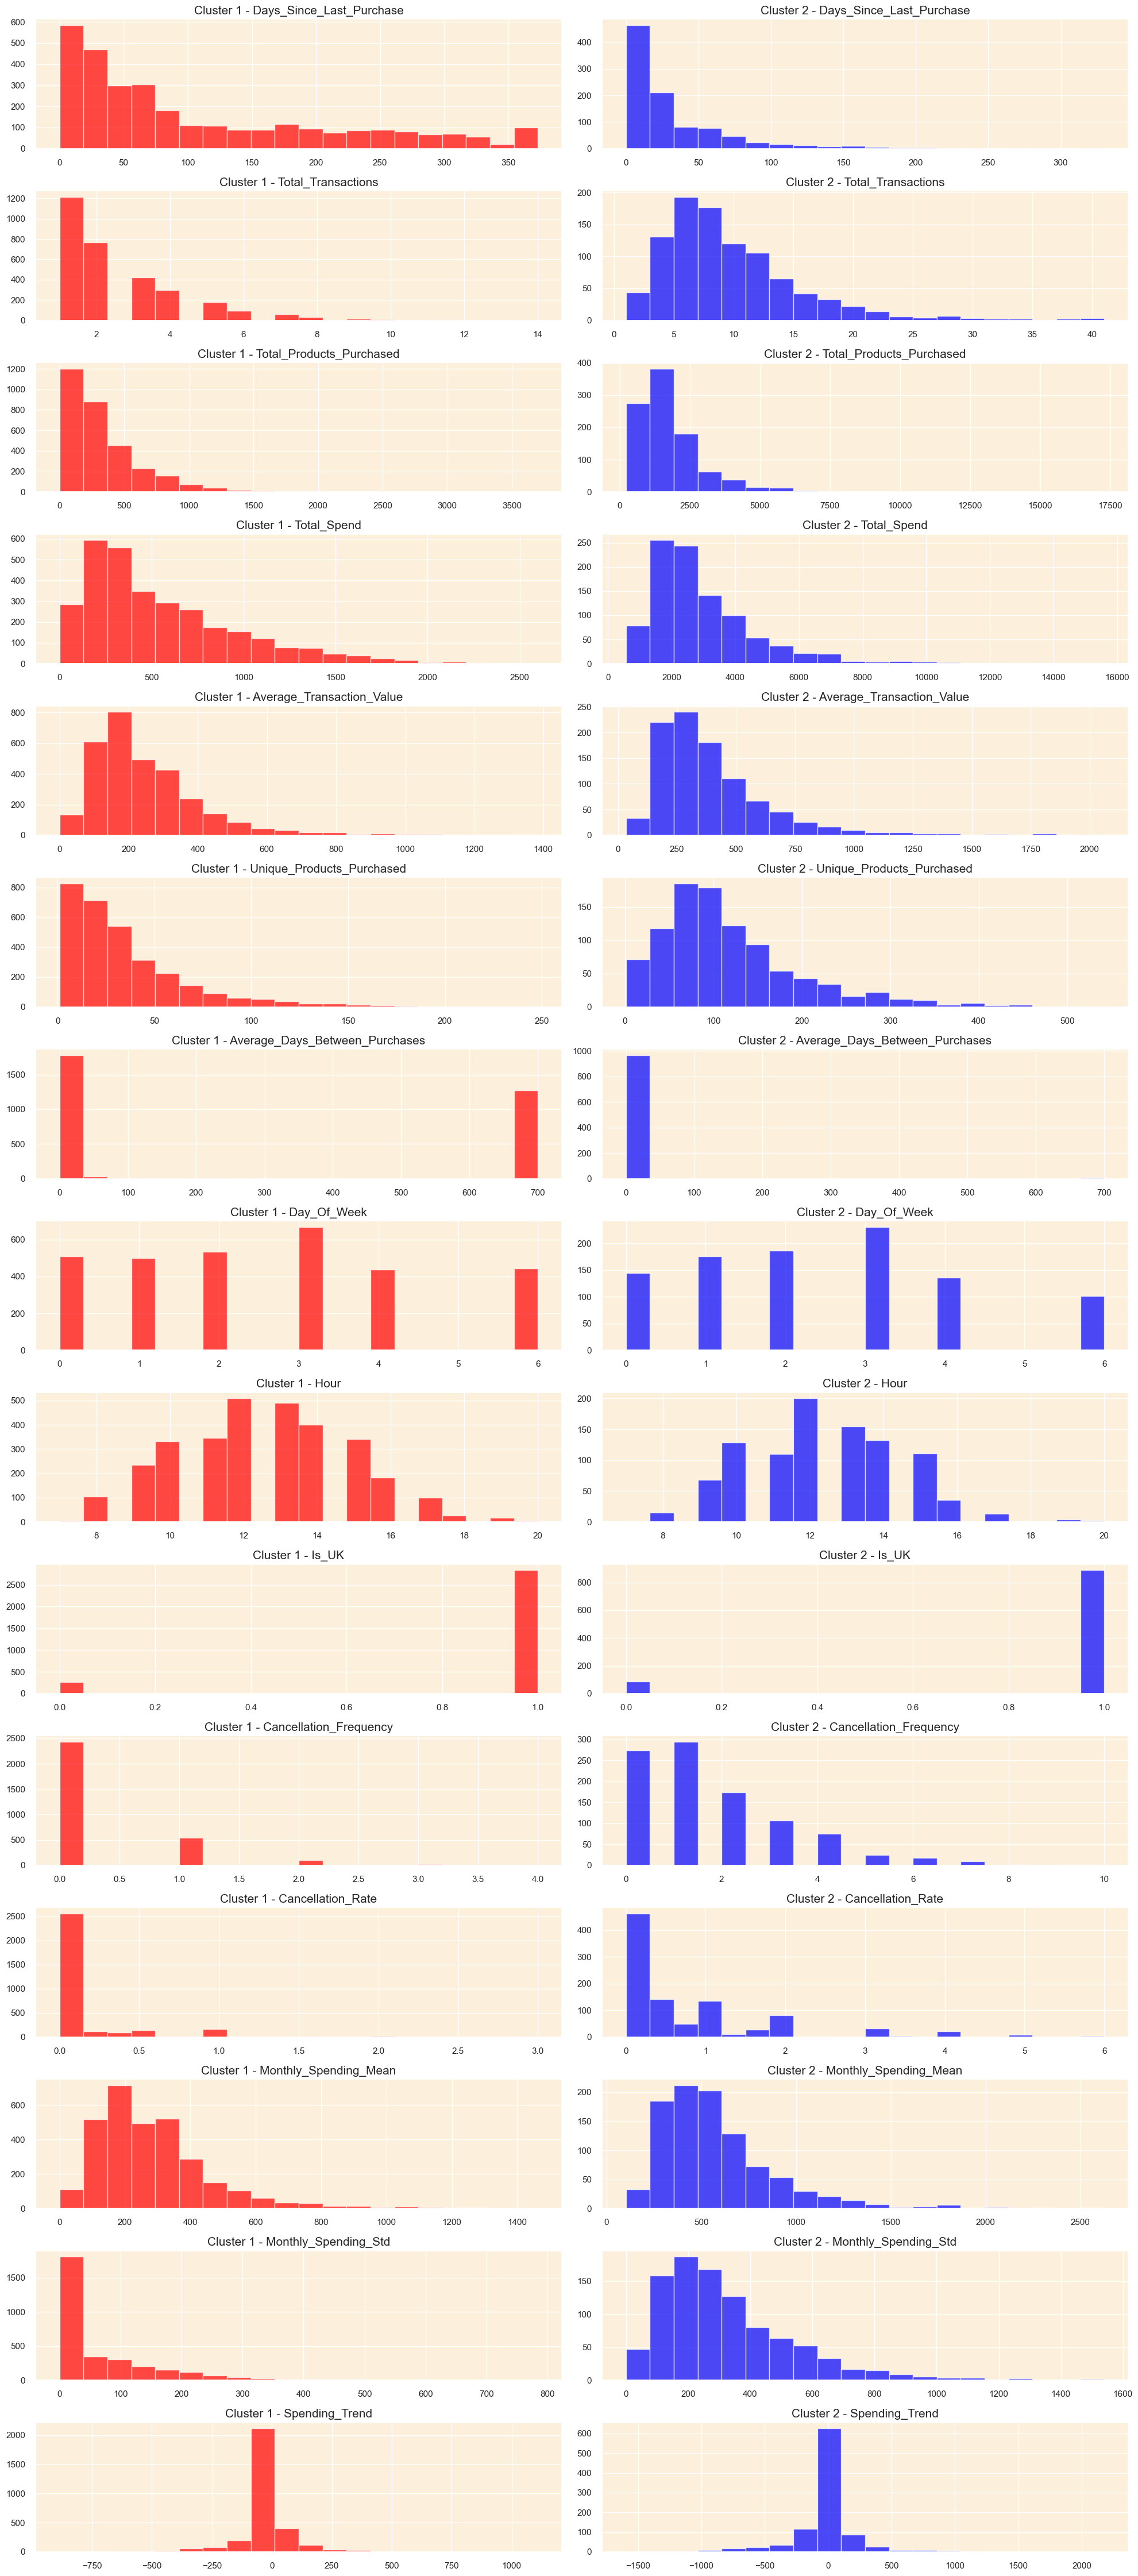

In [18]:
# Plot histograms for each feature segmented by the clusters
features = customer_data_cleaned.columns[1:-1]
clusters = customer_data_cleaned['cluster'].unique()
clusters.sort()

# Setting up the subplots
n_rows = len(features)
n_cols = len(clusters)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))

# Plotting histograms
for i, feature in enumerate(features):
    for j, cluster in enumerate(clusters):
        data = customer_data_cleaned[customer_data_cleaned['cluster'] == cluster][feature]
        axes[i, j].hist(data, bins=20, color=colors[j], edgecolor='w', alpha=0.7)
        axes[i, j].set_title(f'Cluster {cluster} - {feature}', fontsize=15)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel('')

# Adjusting layout to prevent overlapping
plt.tight_layout()
plt.show()

In [19]:
# Xuất ra file csv 2 cột customerID và Cluster

# Create a new DataFrame with only 'CustomerID' and 'cluster' columns
customer_cluster_df = customer_data_cleaned[['CustomerID', 'cluster']]

# Export the DataFrame to a CSV file
customer_cluster_df.to_csv('Data/customer_clusters.csv', index=False)


In [20]:
customer_cluster_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4067 entries, 0 to 4066
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4067 non-null   float64
 1   cluster     4067 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 63.7 KB
